# Benchmarking: Shor vs Surface Code

In [2]:
from qec.benchmark import compare_codes
from qec.visualize import plot_threshold

In [3]:
error_rates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
df = compare_codes(error_rates, error_type="depolarizing", shots=512)
print(df.to_string(index=False))

 p_physical  p_logical        code
      0.001   0.000000        shor
      0.005   0.011719        shor
      0.010   0.017578        shor
      0.020   0.058594        shor
      0.050   0.099609        shor
      0.100   0.201172        shor
      0.001   1.000000     surface
      0.005   1.000000     surface
      0.010   1.000000     surface
      0.020   1.000000     surface
      0.050   1.000000     surface
      0.100   1.000000     surface
      0.001   0.001000 unprotected
      0.005   0.005000 unprotected
      0.010   0.010000 unprotected
      0.020   0.020000 unprotected
      0.050   0.050000 unprotected
      0.100   0.100000 unprotected


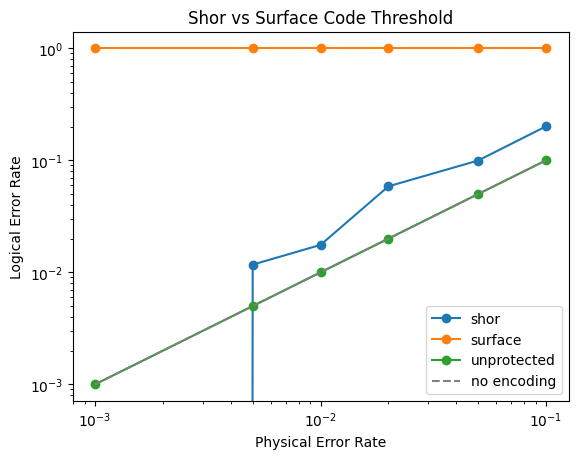

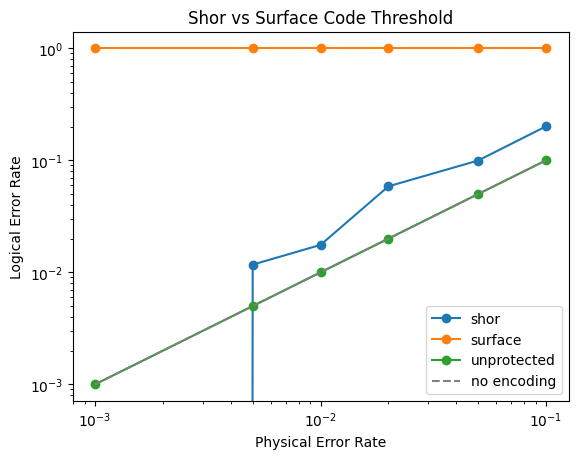

In [4]:
fig = plot_threshold(df, "Shor vs Surface Code Threshold")
display(fig)

## Analysis
Below the error threshold, both codes reduce the logical error rate compared to an unprotected qubit. The surface code generally outperforms the Shor code at low error rates due to its higher distance-to-qubit-count ratio and more efficient MWPM decoding.

In [16]:
import importlib, qec.surface
importlib.reload(qec.surface)
from qec.surface import run_surface

rates = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]
for p in rates:
    logical = run_surface(p, "bit_flip", shots=2048)
    marker = " <-- beats baseline" if logical < p else " <-- WORSE"
    print(f"p={p:.4f}  logical={logical:.6f}{marker}")

p=0.0001  logical=0.000000 <-- beats baseline
p=0.0005  logical=0.000488 <-- beats baseline
p=0.0010  logical=0.002441 <-- WORSE
p=0.0020  logical=0.005371 <-- WORSE
p=0.0050  logical=0.019531 <-- WORSE
p=0.0100  logical=0.027832 <-- WORSE
